In [1]:
# background remove
from rembg import remove
from PIL import Image
import io

In [2]:
# bit mask
import numpy as np
from skimage import measure

In [3]:
# visualize bitmask
import matplotlib.pyplot as plt

In [4]:
# bitmask to vector
import numpy as np
from PIL import Image
import tempfile
import os
import vtracer
from skimage import filters
from skimage.io import imread, imsave

In [5]:
# smooth and simplify vector
import numpy as np
from svgpathtools import svg2paths
from scipy.interpolate import splprep, splev
import svgwrite

In [ ]:
# Remove background and convert to bitmask
# Load input image and remove background
input_path = 'test/images/test4.jpg'  # replace with your image path

img = Image.open(input_path).convert('RGBA')

img_bytes = io.BytesIO()
img.save(img_bytes, format='PNG')
img_bytes = img_bytes.getvalue()

output_bytes = remove(img_bytes)
output_img = Image.open(io.BytesIO(output_bytes)).convert('RGBA')

# --- STEP 2: Threshold the alpha channel ---
alpha = np.array(output_img.split()[-1])  # extract alpha channel
binary_mask = alpha > 0  # threshold: foreground = True, background = False

# --- STEP 3: Extract contours ---
# Find contours at a constant value of 0.5 (True/False boundary)
contours = measure.find_contours(binary_mask, level=0.5)

# --- Visualization ---
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_mask, cmap='gray')
ax[1].set_title('Thresholded Alpha Mask')
ax[1].axis('off')

ax[2].imshow(binary_mask, cmap='gray')
for contour in contours:
    # ax[2].plot(contour[:, 1], contour[:, 0], linewidth=.8, color='white')
    ax[2].fill(contour[:, 1], contour[:, 0], facecolor="white", edgecolor="white", linewidth=1)

ax[2].set_title('Vector Outlines (Contours)')
ax[2].axis('off')

plt.tight_layout()
plt.show()


In [6]:
# remove background
def remove_background(input_path):
    """
    Remove background from an image using rembg
    
    Args:
        input_path (str): Path to input image
        
    Returns:
        PIL.Image: Image with background removed (RGBA format)
    """
    # Load input image and convert to RGBA
    img = Image.open(input_path).convert('RGBA')
    
    # Convert to bytes for rembg processing
    img_bytes = io.BytesIO()
    img.save(img_bytes, format='PNG')
    img_bytes = img_bytes.getvalue()
    
    # Remove background
    output_bytes = remove(img_bytes)
    output_img = Image.open(io.BytesIO(output_bytes)).convert('RGBA')
    
    return img, output_img
# original_img, no_bg_img = remove_background('test/images/test4.jpg')

In [7]:
# bit mask
def create_bitmask_and_contours(rgba_image):
    """
    Create binary mask from RGBA image and extract contours
    
    Args:
        rgba_image (PIL.Image): RGBA image with transparent background
        
    Returns:
        tuple: (binary_mask, contours)
            - binary_mask (numpy.ndarray): Boolean array where True = foreground
            - contours (list): List of contour arrays from skimage.measure.find_contours
    """
    # Extract alpha channel and create binary mask
    alpha = np.array(rgba_image.split()[-1])  # extract alpha channel
    binary_mask = alpha > 0  # threshold: foreground = True, background = False
    
    # Extract contours at the True/False boundary
    contours = measure.find_contours(binary_mask, level=0.5)
    
    return binary_mask, contours

# Usage example:
# binary_mask, contours = create_bitmask_and_contours(no_bg_img)

In [8]:
def visualize_results(original_img, binary_mask, contours):
    """
    Visualize the original image, binary mask, and contours
    
    Args:
        original_img (PIL.Image): Original input image
        binary_mask (numpy.ndarray): Binary mask array
        contours (list): List of contour arrays
    """
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot original image
    ax[0].imshow(original_img)
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    
    # Plot binary mask
    ax[1].imshow(binary_mask, cmap='gray')
    ax[1].set_title('Thresholded Alpha Mask')
    ax[1].axis('off')
    
    # Plot contours on binary mask
    ax[2].imshow(binary_mask, cmap='gray')
    for contour in contours:
        ax[2].fill(contour[:, 1], contour[:, 0], 
                  facecolor="white", edgecolor="white", linewidth=1)
    ax[2].set_title('Vector Outlines (Contours)')
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Usage example:
# visualize_results(original_img, binary_mask, contours)


In [9]:


def convert_to_vector(input_image,output_svg):
    # open image 
    img = Image.open(input_png)

    # convert to numpy array for inversion
    img_array = np.array(img)

    # invert colors using numpy - subtract from max value (255 for 8-bit)
    if img_array.dtype == np.uint8:
        inverted_array = 255 - img_array
    else:
        inverted_array = np.iinfo(img_array.dtype).max - img_array

    # convert back to PIL Image
    inverted_img = Image.fromarray(inverted_array)

    # save in temp file
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as temp_file:
        temp_png_path = temp_file.name
        inverted_img.save(temp_png_path)

    # send temp file to convert_image_to_svg_py
    vtracer.convert_image_to_svg_py(temp_png_path, output_svg, colormode='binary')

    # cleanup temp file
    os.unlink(temp_png_path)
# vectorize
# input_png = "test/images/output_example_2.png"  # Change this to your PNG file path
# output_svg = "test/images/inverted_output2.svg" 

# convert_to_vector(input_png,output_svg)

# using scikit image add the Savitzky–Golay Filter 
# save the output as inverted_output_savitzky_golay.svg

In [ ]:


input_svg = "test/images/inverted_output.svg"
output_svg = "test/images/smoothed_output.svg"
canvas_size = (500, 500)  # canvas size in px

# Load SVG paths
paths, _ = svg2paths(input_svg)

# Use the first path
path = paths[0]

# Sample a reduced number of points from the path
num_sampled_points = 50
points = np.array([path.point(t) for t in np.linspace(0, 1, num_sampled_points)])
x = points.real
y = points.imag

# Smooth with spline
tck, _ = splprep([x, y], s=1)  # lower 's' for tighter fit
u_new = np.linspace(0, 1, 40)  # fewer output points for simplicity
x_smooth, y_smooth = splev(u_new, tck)
smooth_points = np.column_stack((x_smooth, y_smooth))

# Compute bounding box
min_x, min_y = np.min(smooth_points, axis=0)
max_x, max_y = np.max(smooth_points, axis=0)
path_width = max_x - min_x
path_height = max_y - min_y

# Compute translation to center
canvas_width, canvas_height = canvas_size
translate_x = (canvas_width - path_width) / 2 - min_x
translate_y = (canvas_height - path_height) / 2 - min_y
smooth_points_centered = [(x + translate_x, y + translate_y) for x, y in smooth_points]

# Construct path string, close path with 'Z'
d_str = f"M {smooth_points_centered[0][0]},{smooth_points_centered[0][1]} " + \
        " ".join(f"L {x},{y}" for x, y in smooth_points_centered[1:]) + " Z"

# Create SVG with closed black-filled path
dwg = svgwrite.Drawing(output_svg, size=canvas_size)
dwg.add(dwg.path(d=d_str, fill="black", stroke="none"))
dwg.save()


In [10]:
# pipeline
original_img, no_bg_img = remove_background('test/images/test4.jpg')

In [ ]:
# Complete workflow using all three parts
# from bg_removal_part1 import remove_background
# from bitmask_creation_part2 import create_bitmask_and_contours
# from visualization_part3 import visualize_results

# Step 1: Remove background
input_path = 'test/images/test9.jpg'
original_img, no_bg_img = remove_background(input_path)

# Step 2: Create bitmask and extract contours
binary_mask, contours = create_bitmask_and_contours(no_bg_img)

# Step 3: Visualize results
visualize_results(original_img, binary_mask, contours)

In [12]:
def image_processs_pipeline(input_path):
    original_img, no_bg_img = remove_background(input_path)

    # Step 2: Create bitmask and extract contours
    binary_mask, contours = create_bitmask_and_contours(no_bg_img)
    
    # Step 3: Visualize results
    visualize_results(original_img, binary_mask, contours)

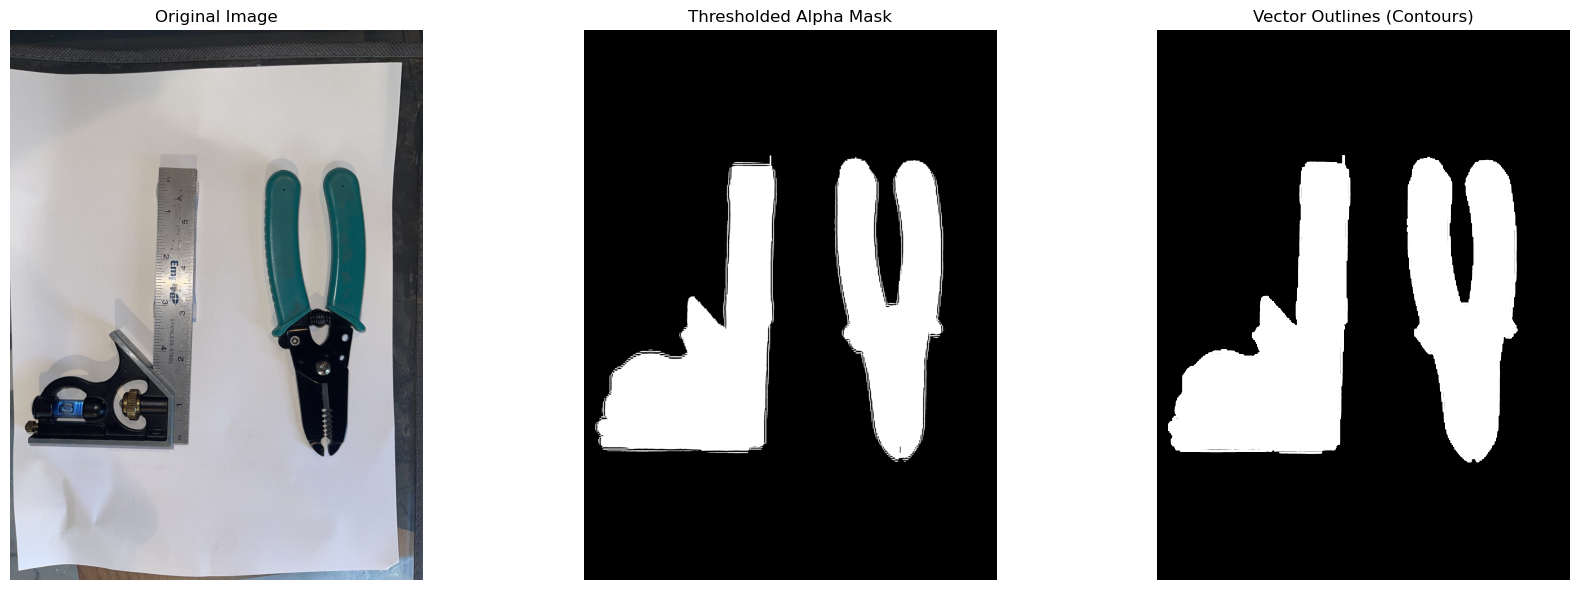

In [20]:
image_processs_pipeline('test/images/test10.jpg')

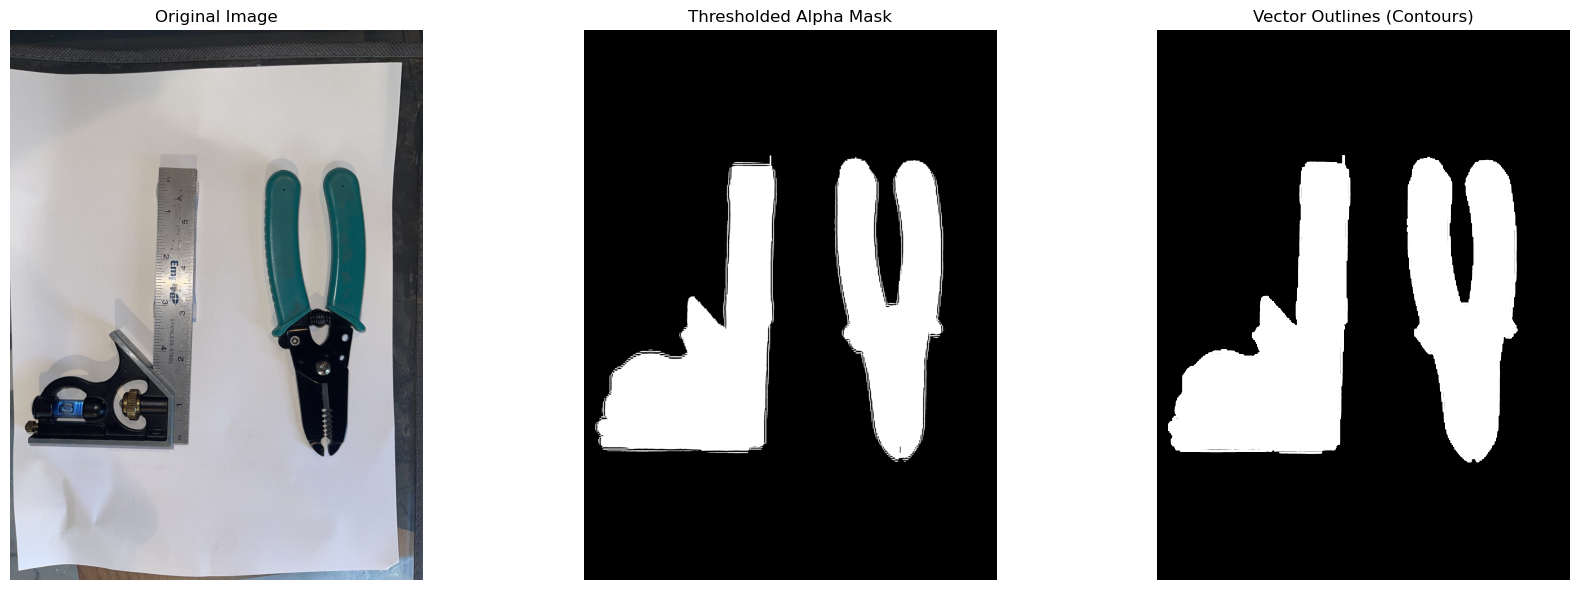

In [21]:
image_processs_pipeline('test/images/test9.jpg')

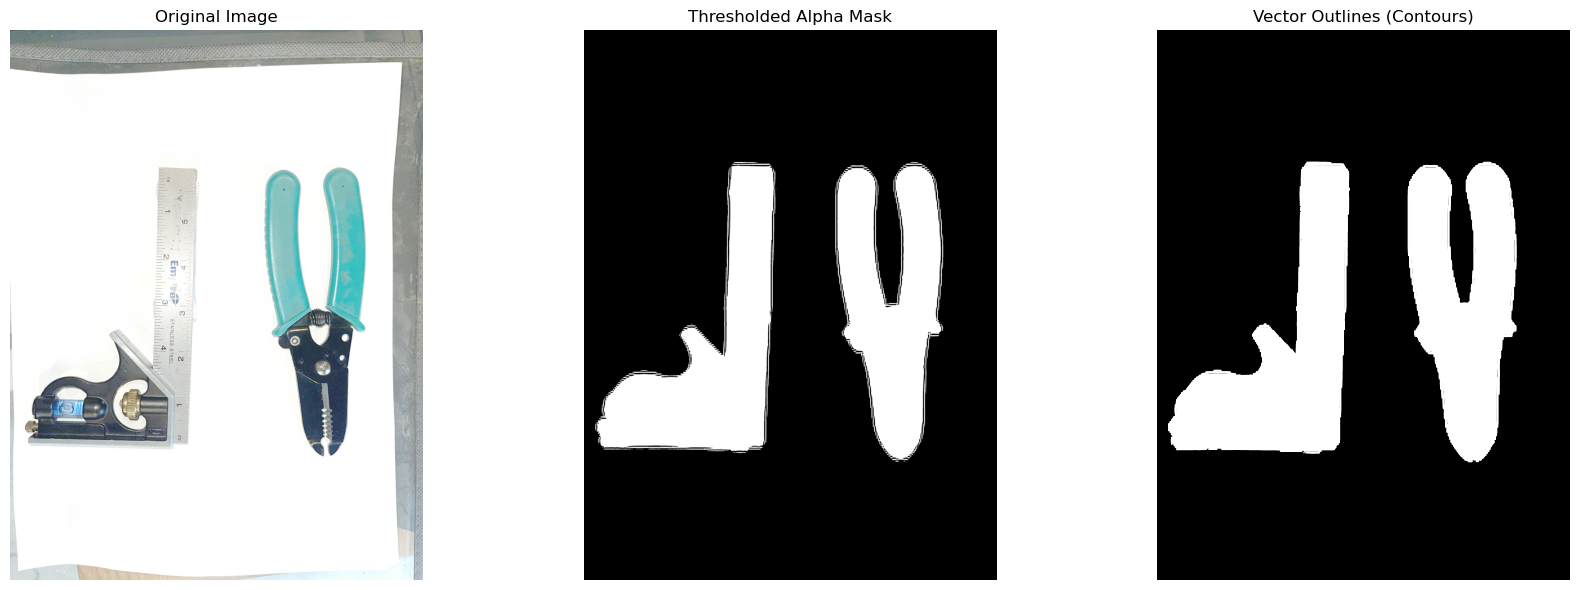

In [13]:
image_processs_pipeline('test/images/test10_2.jpg')